# P.6. Callable Agency Bond OAS Strategy


## Project Statement

Analyze a panel of callable agency bonds (Freddie Mac, Fannie Mae, FHLB), construct a mean-reversion trading strategy based on OAS z-scores, and decompose the strategy’s P&L into spread compression, option repricing, and carry components across the 2022–2025 rate cycle.


## Context

### Agency Callable Bonds and the Ch 6 Framework

Agency callable bonds are the canonical application of the OAS framework from Ch 6. The bondholder is short an embedded call option: the issuer (Freddie Mac, Fannie Mae, or FHLB) can redeem the bond at par after the first call date. This creates the decomposition:

$$\text{Z-spread} = \text{OAS} + \text{Option Cost}$$

The **Z-spread** is the flat spread over the swap curve needed to match the bond's market price, ignoring the call option. The **OAS** (option-adjusted spread) accounts for the issuer's call right using a rate model. The difference is the **option cost**—the compensation the bondholder demands for being short the call.

### Why OAS for Trading Signals

Raw spread measures (Z-spread, yield spread) conflate two effects: (1) whether the bond is cheap or expensive relative to its credit, and (2) whether the embedded option is expensive or cheap. When implied volatility rises, the option cost increases, widening the Z-spread even if the bond's credit hasn't changed. A naive Z-spread signal would misidentify this as a buying opportunity.

OAS strips out the option effect. If OAS is wide relative to recent history (after accounting for the call), the bond is genuinely cheap. A mean-reversion strategy buys wide-OAS bonds and sells tight-OAS bonds, betting on spread normalization.

### The 2022–2025 Rate Cycle

The sample period spans a dramatic rate environment:

| Period              | Regime            | Fed Funds      | Effect on Callables                              |
|---------------------|-------------------|----------------|--------------------------------------------------|
| Jan 2022 – Sep 2022 | Hiking starts     | 0.25% → ~3.25% | High-coupon calls go from ITM to ATM             |
| Oct 2022 – Jun 2023 | Aggressive hiking | ~3.25% → 5.25% | Calls move OTM, option cost changes dramatically |
| Jul 2023 – Aug 2024 | Pause at peak     | 5.25–5.50%     | Stable option cost, carry matters                |
| Sep 2024 – Dec 2025 | Easing begins     | 5.50% → 4.50%+ | Calls drift back toward ATM                      |

This creates rich variation in call moneyness, option cost, and OAS behavior—exactly the variation needed to study when and why an OAS-based strategy works.

## Resources

### Course Materials

| Material | Relevance |
|----------|-----------|
| **D.5.1 Swap Rates and Spreads** | Swap curve as benchmark for agency spreads, swap spread dynamics |
| **D.6.1 Callable Bonds** | OAS, option cost, negative convexity, Black's formula for the call |
| **E.6.2 Pricing a Callable Bond** | Single-bond OAS calculation (this project scales to a panel) |
| **C.6.1 Callable Bond Analysis** | Freddie Mac callable bond case study |

### External Reading

- [FHLB Office of Finance — Debt Securities](https://www.fhlb-of.com/ofweb_userWeb/pageBuilder/debt-securities-702) — Overview of FHLB callable bond issuance
- [Fannie Mae — Debt Securities](https://capitalmarkets.fanniemae.com/debt-securities) — Fannie Mae callable debt programs
- [NY Fed — Agency Debt and MBS Purchase Program](https://www.newyorkfed.org/markets/agency-debt-and-agency-mbs) — Fed purchases, agency market structure and supply dynamics

### Data Files

| File | Description | Frequency | Date Range |
|------|-------------|-----------|------------|
| `callable_agency_panel_{DATE}.xlsx` | Panel of agency callable bonds (OAS, prices, analytics) | Daily | 2022–2025 |
| `sofr_swaps.xlsx` | SOFR swap curve (41 maturities) | Daily | 2018–2025 |
| `gsw_yields.xlsx` | GSW zero-coupon Treasury yields (1–30Y) | Daily | 1961–2025 |
| `ref_rates.xlsx` | SOFR, Fed Funds, 3M T-bill | Daily | 2018–2025 |

**Panel structure**: The callable agency panel contains 26 bonds from Freddie Mac, Fannie Mae, and FHLB, spanning coupons from ~1% to ~5.5% and maturities from 2027 to 2036. The Excel file contains:

| Sheet | Description | Coverage |
|-------|-------------|----------|
| `info` | Static properties (coupon, maturity, call dates, issuer) | All 26 bonds |
| `quotes` | Snapshot analytics (OAS, Z-spread, eff. duration, eff. convexity, implied vol) | 16 bonds with live analytics |
| `oas` | Daily OAS time series | 25 bonds, 2022–2025 |
| `z_spread` | Daily Z-spread time series | 15 bonds |
| `option_cost` | Daily option cost = Z-spread − OAS | 15 bonds |
| `clean_prices` / `dirty_prices` | Daily prices | 15 bonds |
| `ytm` | Daily yield to maturity | 15 bonds |

**Note:** 25 bonds have OAS time series; 15 bonds also have Z-spread, prices, and option cost. The OAS-based strategy in Q2 can use all 25 bonds; the return decomposition in Q3 uses the 15 bonds with price data. Effective duration and convexity are available as snapshots only (in `quotes`), not as time series — use the snapshot values as constant approximations, or compute numerical duration from prices if you wish. Some high-coupon bonds in the panel were previously called by issuers; these retain historical OAS time series but lack current snapshot analytics (NaN in the `quotes` sheet). Be aware that bonds called by issuers during the sample period drop out of the panel — this survivorship effect may bias backtested returns, particularly for high-coupon bonds.

## Data Preview


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

DATA_PATH = Path('_DATA')

In [2]:
# Load callable agency panel (use most recent file)
panel_file = sorted(DATA_PATH.glob('callable_agency_panel_*.xlsx'))[-1]
print(f'Panel file: {panel_file.name}')

info = pd.read_excel(panel_file, sheet_name='info', index_col=0)
quotes = pd.read_excel(panel_file, sheet_name='quotes', index_col=0)
oas = pd.read_excel(panel_file, sheet_name='oas', index_col=0, parse_dates=True)
zsprd = pd.read_excel(panel_file, sheet_name='z_spread', index_col=0, parse_dates=True)
opt_cost = pd.read_excel(panel_file, sheet_name='option_cost', index_col=0, parse_dates=True)
clean = pd.read_excel(panel_file, sheet_name='clean_prices', index_col=0, parse_dates=True)
dirty = pd.read_excel(panel_file, sheet_name='dirty_prices', index_col=0, parse_dates=True)

oas.index = pd.to_datetime(oas.index)
zsprd.index = pd.to_datetime(zsprd.index)
opt_cost.index = pd.to_datetime(opt_cost.index)
clean.index = pd.to_datetime(clean.index)
dirty.index = pd.to_datetime(dirty.index)

print(f'Static bonds: {len(info.columns)}')
print(f'OAS time series: {oas.shape[1]} bonds, {oas.shape[0]} dates')
print(f'Prices/Z-spread: {clean.shape[1]} bonds')
print(f'Date range: {oas.index[0].date()} to {oas.index[-1].date()}')

Panel file: callable_agency_panel_2026-03-03.xlsx
Static bonds: 26
OAS time series: 25 bonds, 1043 dates
Prices/Z-spread: 15 bonds
Date range: 2022-01-03 to 2025-12-31


In [3]:
# Load supporting data
swaps = pd.read_excel(DATA_PATH / 'sofr_swaps.xlsx', sheet_name='data',
                       index_col=0, parse_dates=True)
swaps.index = pd.to_datetime(swaps.index)

gsw = pd.read_excel(DATA_PATH / 'gsw_yields.xlsx', index_col=0, parse_dates=True)
gsw.index = pd.to_datetime(gsw.index)

rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data',
                       index_col=0, parse_dates=True)
rates.index = pd.to_datetime(rates.index)

In [4]:
# Snapshot: bond properties and analytics
print('Bond Properties:')
display(info)

print('\nSnapshot Analytics:')
display(quotes)

Bond Properties:


,FHLB 2 01/28/31,FHLB 2 09/15/31,FHLB 4.25 03/28/30,FHLB 4.25 12/28/28,FHLB 4.75 06/15/28,FHLB 5 01/15/30,FHLB 5 09/28/32,FHLB 5 12/15/27,FHLB 5.25 03/28/29,FHLB 5.5 12/28/28,...,FHLMC 5.5 09/28/28,FNMA 1 09/28/29,FNMA 1.5 09/28/35,FNMA 5 03/15/30,FHLB 4.875 01/28/36,FHLB 4.875 09/28/28,FHLB 5.125 05/15/29,FHLB 5.25 05/15/35,FHLB 5.375 12/15/34,FHLB 5.5 05/15/34
info,,,,,,,,,,,,,,,,,,,,,
CUSIP,3130AKTB2,3130ANWL0,3130B5Q50,3130AYLD6,3130B6TU0,3130B4KU4,3130ATBY2,3130B43K5,3130B0M55,NaN,...,NaN,3136G44J9,3136G44Q3,3136GADR7,3130B96U9,3130B1GC5,3130B1HQ3,3130B65Z5,3130B4B59,3130B1EY9
Issuer,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,...,FREDDIE MAC,FANNIE MAE,FANNIE MAE,FANNIE MAE,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK
Maturity Type,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,NaN,...,NaN,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE
Amount Issued,30000000,50000000,30000000,60000000,50000000,100000000,50000000,230000000,40000000,NaN,...,NaN,50000000,25000000,15000000,55000000,25000000,30000000,105000000,20000000,15000000
Cpn Rate,0.02,0.02,0.0425,0.0425,0.0475,0.05,0.05,0.05,0.0525,0.055,...,0.055,0.01,0.015,0.05,0.04875,0.04875,0.05125,0.0525,0.05375,0.055
Cpn Freq,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Date Issued,2021-01-28 00:00:00,2021-09-15 00:00:00,2025-03-28 00:00:00,2024-01-19 00:00:00,2025-06-30 00:00:00,2025-01-15 00:00:00,2022-09-28 00:00:00,2024-12-27 00:00:00,2024-03-28 00:00:00,NaN,...,NaN,2020-09-28 00:00:00,2020-09-28 00:00:00,2025-03-28 00:00:00,2026-01-28 00:00:00,2024-05-20 00:00:00,2024-05-29 00:00:00,2025-05-15 00:00:00,2024-12-18 00:00:00,2024-05-15 00:00:00
Date Matures,2031-01-28 00:00:00,2031-09-15 00:00:00,2030-03-28 00:00:00,2028-12-28 00:00:00,2028-06-15 00:00:00,2030-01-15 00:00:00,2032-09-28 00:00:00,2027-12-15 00:00:00,2029-03-28 00:00:00,2028-12-28 00:00:00,...,2028-09-28 00:00:00,2029-09-28 00:00:00,2035-09-28 00:00:00,2030-03-15 00:00:00,2036-01-28 00:00:00,2028-09-28 00:00:00,2029-05-15 00:00:00,2035-05-15 00:00:00,2034-12-15 00:00:00,2034-05-15 00:00:00
Date First Call,2021-04-28 00:00:00,2021-12-15 00:00:00,2028-03-28 00:00:00,2027-06-28 00:00:00,2025-09-15 00:00:00,2026-01-15 00:00:00,2023-09-28 00:00:00,2025-01-15 00:00:00,2025-03-28 00:00:00,NaN,...,NaN,2022-09-28 00:00:00,2022-09-28 00:00:00,2025-09-15 00:00:00,2026-07-28 00:00:00,2026-09-28 00:00:00,2026-05-15 00:00:00,2026-05-15 00:00:00,2027-06-15 00:00:00,2026-05-15 00:00:00



Snapshot Analytics:


,FHLB 2 01/28/31,FHLB 2 09/15/31,FHLB 4.25 03/28/30,FHLB 4.25 12/28/28,FHLB 4.75 06/15/28,FHLB 5 01/15/30,FHLB 5 09/28/32,FHLB 5 12/15/27,FHLB 5.25 03/28/29,FHLB 5.5 12/28/28,...,FHLMC 5.5 09/28/28,FNMA 1 09/28/29,FNMA 1.5 09/28/35,FNMA 5 03/15/30,FHLB 4.875 01/28/36,FHLB 4.875 09/28/28,FHLB 5.125 05/15/29,FHLB 5.25 05/15/35,FHLB 5.375 12/15/34,FHLB 5.5 05/15/34
quotes,,,,,,,,,,,,,,,,,,,,,
Accrued Interest,0.188889,0.927778,1.818056,0.755556,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,NaN,0.427778,0.641667,0.00000,0.487500,2.112500,1.551736,1.589583,1.179514,1.665278
TTM,4.911704,5.541410,4.073922,2.828200,2.291581,3.876797,6.579055,1.790554,3.074606,2.83,...,2.58,3.578371,9.577002,4.03833,9.905544,2.573580,3.200548,9.199179,8.785763,8.199863
Clean Price,92.204000,90.884000,101.047500,100.623500,NaN,NaN,99.950000,NaN,NaN,NaN,...,NaN,91.526000,77.997500,NaN,98.802500,100.583000,100.293000,100.085500,101.521500,100.264500
Dirty Price,92.392889,91.811778,102.865556,101.379056,NaN,NaN,101.450000,NaN,NaN,NaN,...,NaN,91.953778,78.639167,NaN,99.290000,102.695500,101.844736,101.675083,102.701014,101.929778
OAS Spread,25.089774,26.286636,8.646127,16.688964,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,11.289233,38.437925,NaN,26.830083,15.776629,-11.419941,-0.305686,21.386575,9.724973
Implied Vol,0.000000,21.022839,24.465900,25.266815,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22.447554,17.836895,NaN,19.316908,23.623610,23.538460,19.325924,20.898499,19.929138
Eff Duration,4.590908,5.100778,1.935088,1.267526,NaN,NaN,5.552307,NaN,NaN,NaN,...,NaN,3.437918,8.588169,NaN,7.723488,0.544429,0.195842,0.195397,1.216841,0.195648
Eff Convexity,0.239862,0.296774,0.048317,0.022526,NaN,NaN,0.370041,NaN,NaN,NaN,...,NaN,0.136820,0.824861,NaN,0.724161,0.005691,0.000767,0.000764,0.021063,0.000766
YTM Maturity,3.754571,3.843629,3.968195,4.012296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.546405,4.332371,NaN,5.029421,4.630127,5.022059,5.237044,5.156153,5.458193


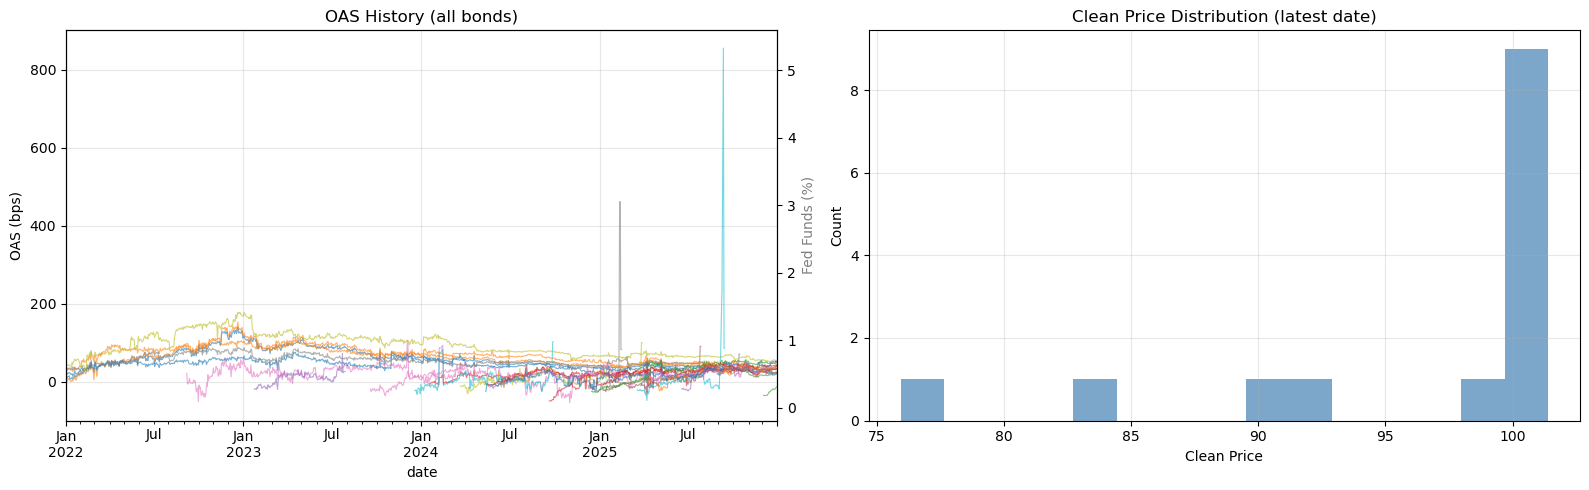

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# OAS time series
oas.plot(ax=axes[0], alpha=0.6, linewidth=0.8, legend=False)
axes[0].set_ylabel('OAS (bps)')
axes[0].set_title('OAS History (all bonds)')
axes[0].grid(True, alpha=0.3)

# Fed Funds rate for context
ff = rates.loc['2022':'2025', 'DFF']
ax2 = axes[0].twinx()
ax2.plot(ff.index, ff, 'k--', linewidth=1, alpha=0.4, label='Fed Funds')
ax2.set_ylabel('Fed Funds (%)', color='gray')

# Clean price distribution
clean.iloc[-1].dropna().hist(ax=axes[1], bins=15, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Clean Price')
axes[1].set_ylabel('Count')
axes[1].set_title('Clean Price Distribution (latest date)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Formulas

### Spread Decomposition (D.6.1)

$$\text{Z-spread} = \text{OAS} + \text{Option Cost}$$

The **Z-spread** prices the bond ignoring the embedded call. The **OAS** accounts for the issuer's call right. The difference is the **option cost**—the compensation for being short the call.

### Rolling Z-Score (Q2)

$$z_t = \frac{\text{OAS}_t - \overline{\text{OAS}}_{t-W:t}}{\sigma(\text{OAS}_{t-W:t})}$$

where $W$ is the rolling window (e.g., 60 trading days). A z-score above 1 means the bond is cheap relative to recent history; below $-1$ means expensive.

### Approximate Bond Return (Q2, Q3)

$$r_{\text{bond}} \approx -D_{\text{eff}} \times \frac{\Delta\text{OAS}}{10{,}000}$$

This spread-driven return approximation is used in Q2 for backtesting and refined in Q3 with carry and residual components.

### Return Decomposition (Q3)

For a bond with effective duration $D_{\text{eff}}$:

$$\text{Total Return} \approx \underbrace{\text{Coupon Accrual} - \text{Funding Cost}}_{\text{Carry}} + \underbrace{(-D_{\text{eff}} \times \Delta\text{OAS})}_{\text{Spread Return}} + \text{Residual}$$

The residual captures option repricing, curve moves, and model error.

where the carry component is:

$$\text{Carry (monthly)} = \frac{\text{Coupon}/12 - r_{\text{SOFR}} \times P_{\text{dirty}} / 12}{P_{\text{dirty}}}$$

and $r_{\text{SOFR}}$ is the annualized SOFR rate, $P_{\text{dirty}}$ is the dirty price at the start of the month.

### Call Moneyness (Q1)

$$\text{Call Moneyness} = \text{Coupon Rate} - s(T)$$

where $s(T)$ is the swap rate at the bond's maturity. Positive moneyness means the call is in the money (issuer has incentive to call).

## Questions


### Question 1: Cross-Section Anatomy

**Map the callable bond universe by its key characteristics and identify which bonds have the most expensive embedded calls.**

a) For each bond in the panel, compute the **call moneyness**: the difference between the bond's coupon rate and the current swap rate at the bond's maturity (interpolate the swap curve as needed). Positive moneyness means the call is in the money (the issuer has an incentive to call). Present the results in a table.

b) Compute the **option cost** for each bond: $\text{Option Cost} = \text{Z-spread} - \text{OAS}$ (both over the swap curve). Create a scatter plot of call moneyness vs. option cost. Describe the relationship. If implied vol data is available in the snapshot, compare it to option cost — how closely do they track across the moneyness spectrum?

c) Create a visualization showing how **effective duration** and **effective convexity** vary across the panel. Which bonds exhibit the most negative convexity? How does this relate to call moneyness?

d) Group bonds into three categories: deep OTM callables (moneyness < −100 bps), near-ATM callables (−100 to +100 bps), and deep ITM callables (moneyness > +100 bps), or justify alternative cutoffs. Summarize how OAS, option cost, duration, and convexity differ across groups.

e) Which moneyness group looks most attractive for a spread strategy, and why?

In [6]:
print(swaps.columns.tolist())
print(swaps.iloc[-1].head())

[0.08333333333333333, 0.1666666666666667, 0.25, 0.3333333333333333, 0.4166666666666667, 0.5, 0.5833333333333334, 0.6666666666666666, 0.75, 0.8333333333333334, 0.9166666666666666, 1.0, 1.083333333333333, 1.166666666666667, 1.25, 1.333333333333333, 1.416666666666667, 1.5, 1.583333333333333, 1.666666666666667, 1.75, 1.833333333333333, 1.916666666666667, 2.0, 2.25, 2.5, 2.75, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0]
0.083333    4.33155
0.166667    4.32874
0.250000    4.30190
0.333333    4.25581
0.416667    4.20350
Name: 2025-06-30 00:00:00, dtype: float64


In [7]:
coupons = info.loc['Cpn Rate'].dropna()
print(coupons.head())

FHLB 2 01/28/31         0.02
FHLB 2 09/15/31         0.02
FHLB 4.25 03/28/30    0.0425
FHLB 4.25 12/28/28    0.0425
FHLB 4.75 06/15/28    0.0475
Name: Cpn Rate, dtype: object


Since the quotes snapshot has up to March 3, 2026 but the oas time series and zsprd time series only has up until December 31, 2025 and the Swap rates only has data up until June 30 2025, we use June 30, 2025 for all for consistency.

In [8]:
print("Last swap date:", swaps.index[-1])
print("Last OAS date:", oas.index[-1])
print("Last zsprd date:", zsprd.index[-1])
print("Last clean price date:", clean.index[-1])

Last swap date: 2025-06-30 00:00:00
Last OAS date: 2025-12-31 00:00:00
Last zsprd date: 2025-12-31 00:00:00
Last clean price date: 2025-12-31 00:00:00


#### 1A. Calculating moneyness of each bond relative to swap curve

In [9]:
# #1A w/ June 2025 data) Calculating moneyness of each bond relative to swap curve
# # Latest swap curve
# anchor_date = swaps.index[-1]  # June 30, 2025

# swap_anchor = swaps.loc[anchor_date].dropna()
# swap_tenors = swap_anchor.index.astype(float).values
# swap_rates = swap_anchor.values

# oas_latest = oas.loc[:anchor_date].iloc[-1]
# zsprd_latest = zsprd.loc[:anchor_date].iloc[-1]
# common_bonds = zsprd.columns.intersection(oas.columns)
# option_cost = zsprd_latest[common_bonds] - oas_latest[common_bonds]

# # Bond TTM and coupons
# ttm = quotes.loc['TTM']
# coupons = info.loc['Cpn Rate'] * 100  # convert to percent (0.05 -> 5.0)

# # Compute moneyness for each bond
# results = []
# for bond in ttm.index:
#     if pd.isna(ttm[bond]) or pd.isna(coupons[bond]):
#         continue
#     s_T = np.interp(ttm[bond], swap_tenors, swap_rates)
#     m = coupons[bond] - s_T  # both in percent
#     results.append({
#         'Bond': bond,
#         'Coupon (%)': coupons[bond],
#         'TTM': round(ttm[bond], 2),
#         'Swap Rate s(T) (%)': round(s_T, 4),
#         'Moneyness (bps)': round(m * 100, 1)  # convert pct to bps
#     })

# moneyness_df = pd.DataFrame(results).set_index('Bond').sort_values('Moneyness (bps)', ascending=False)
# print(moneyness_df)

In [10]:
# Latest swap curve
latest_swap = swaps.iloc[-1].dropna()
swap_tenors = latest_swap.index.astype(float).values
swap_rates = latest_swap.values  # in percent, e.g. 4.5 means 4.5%

# Bond TTM and coupons
ttm = quotes.loc['TTM']
coupons = info.loc['Cpn Rate'] * 100  # convert to percent (0.05 -> 5.0)

# Compute moneyness for each bond
results = []
for bond in ttm.index:
    if pd.isna(ttm[bond]) or pd.isna(coupons[bond]):
        continue
    s_T = np.interp(ttm[bond], swap_tenors, swap_rates)
    m = coupons[bond] - s_T  # both in percent
    results.append({
        'Bond': bond,
        'Coupon (%)': coupons[bond],
        'TTM': round(ttm[bond], 2),
        'Swap Rate s(T) (%)': round(s_T, 4),
        'Moneyness (bps)': round(m * 100, 1)  # convert pct to bps
    })

moneyness_df = pd.DataFrame(results).set_index('Bond').sort_values('Moneyness (bps)', ascending=False)
print(moneyness_df)

                     Coupon (%)   TTM  Swap Rate s(T) (%)  Moneyness (bps)
Bond                                                                      
FHLB 5.5 12/28/28         5.500  2.83              3.4028            209.7
FHLMC 5.5 09/28/28        5.500  2.58              3.4135            208.6
FHLB 5.5 05/15/34         5.500  8.20              3.5950            190.5
FHLMC 5.25 01/28/30       5.250  3.91              3.3969            185.3
FHLB 5.25 03/28/29        5.250  3.07              3.3991            185.1
FHLB 5.375 12/15/34       5.375  8.79              3.6253            175.0
FHLB 5.125 05/15/29       5.125  3.20              3.3988            172.6
FHLB 5.25 05/15/35        5.250  9.20              3.6464            160.4
FHLB 5 01/15/30           5.000  3.88              3.3970            160.3
FNMA 5 03/15/30           5.000  4.04              3.3979            160.2
FHLB 5 09/28/32           5.000  6.58              3.5080            149.2
FHLB 5 12/15/27          

#### 1b. Compute option cost (z spread - OAS) over swap curve. 

In [11]:
print(quotes.index.tolist())

['Accrued Interest', 'TTM', 'Clean Price', 'Dirty Price', 'OAS Spread', 'Implied Vol', 'Eff Duration', 'Eff Convexity', 'YTM Maturity', 'YTM Call', 'Tsy Spread']


In [12]:
#print last date for option cost sheet
print(opt_cost.index[-1].date())
#print last date for OAS sheet
print(oas.index[-1].date())


2025-12-31
2025-12-31


In [13]:
#1B) Compute option cost (z spread - OAS) over swap curve. 
#    Create a scatter plot of call moneyness vs. option cost. Describe the relationship.
#    If implied vol data is available in the snapshot, compare it to option cost — how closely do they track across the moneyness spectrum?
# All anchored to December 31, 2025 — latest available for all sheets
common_bonds = zsprd.columns.intersection(oas.columns)
zsprd_latest = zsprd.iloc[-1] # Dec 31, 2025 from z-spread sheet
oas_latest = oas.iloc[-1] # Dec 31, 2025 from OAS sheet

# Compute explicitly as instructed
option_cost_computed = zsprd_latest[common_bonds] - oas_latest[common_bonds]

implied_vol = quotes.loc['Implied Vol'].astype(float) # March 2026 snapshot from quotes sheet


q1b = pd.DataFrame({
    'Moneyness (bps)': moneyness_df['Moneyness (bps)'],
    'Option Cost (bps)': option_cost_computed,
    'Implied Vol': implied_vol
}).dropna(subset=['Option Cost (bps)'])

print(q1b)

                     Moneyness (bps)  Option Cost (bps)  Implied Vol
FHLB 2 09/15/31               -145.5             29.411    21.022839
FHLB 4.25 03/28/30              85.1             51.310    24.465900
FHLB 4.25 12/28/28              84.7             35.801    25.266815
FHLB 4.875 09/28/28            146.1              6.368    23.623610
FHLB 5 09/28/32                149.2            471.678          NaN
FHLB 5.125 05/15/29            172.6             -0.458    23.538460
FHLB 5.25 05/15/35             160.4            110.764    19.325924
FHLB 5.375 12/15/34            175.0             67.868    20.898499
FHLB 5.5 05/15/34              190.5             60.779    19.929138
FHLMC 1 12/28/28              -240.3             18.906    22.676838
FHLMC 1.5 01/28/33            -202.6             23.421    20.182705
FHLMC 3.75 06/28/30             34.3             53.074    23.649389
FHLMC 4 09/28/29                60.2             30.351    22.447554
FNMA 1.5 09/28/35             -216

In [14]:
print("Bonds in option_cost_computed:", set(option_cost_computed.dropna().index))
print("Bonds in moneyness_df:", set(moneyness_df.index))
print("\nIn option_cost but not moneyness:", 
      set(option_cost_computed.dropna().index) - set(moneyness_df.index))
print("In moneyness but not option_cost:", 
      set(moneyness_df.index) - set(option_cost_computed.dropna().index))

Bonds in option_cost_computed: {'FHLB 5.25 05/15/35', 'FHLMC 1 12/28/28', 'FHLMC 3.75 06/28/30', 'FHLB 5.5 05/15/34', 'FHLMC 4 09/28/29', 'FHLB 5.375 12/15/34', 'FNMA 1.5 09/28/35', 'FHLMC 1.5 01/28/33', 'FHLB 5.125 05/15/29', 'FHLB 4.25 12/28/28', 'FHLB 4.875 09/28/28', 'FHLB 5 09/28/32', 'FHLB 2 09/15/31', 'FHLB 4.25 03/28/30'}
Bonds in moneyness_df: {'FHLB 5.5 05/15/34', 'FHLMC 4 09/28/29', 'FHLB 5.25 03/28/29', 'FHLB 5.125 05/15/29', 'FHLB 5 09/28/32', 'FNMA 5 03/15/30', 'FHLB 2 09/15/31', 'FHLB 4.25 03/28/30', 'FHLMC 5.5 09/28/28', 'FNMA 1 09/28/29', 'FHLB 5.375 12/15/34', 'FHLB 5 01/15/30', 'FHLB 2 01/28/31', 'FHLMC 3.75 06/28/30', 'FHLB 4.875 01/28/36', 'FHLB 5.5 12/28/28', 'FNMA 1.5 09/28/35', 'FHLMC 1.5 01/28/33', 'FHLB 4.875 09/28/28', 'FHLB 5 12/15/27', 'FHLB 5.25 05/15/35', 'FHLMC 1 12/28/28', 'FHLMC 5.25 01/28/30', 'FHLB 4.75 06/15/28', 'FHLB 4.25 12/28/28', 'FHLMC 4.75 01/28/28'}

In option_cost but not moneyness: set()
In moneyness but not option_cost: {'FHLB 4.875 01/28

In [15]:
#compare to the option cost sheet
option_cost_sheet = opt_cost.iloc[-1] # Dec 31, 2025 from option cost sheet
comparison_df = pd.DataFrame({
    'Computed Option Cost (bps)': option_cost_computed,
    'Sheet Option Cost (bps)': option_cost_sheet
}).dropna()
print(comparison_df)

                     Computed Option Cost (bps)  Sheet Option Cost (bps)
FHLB 2 09/15/31                          29.411                   29.411
FHLB 4.25 03/28/30                       51.310                   51.310
FHLB 4.25 12/28/28                       35.801                   35.801
FHLB 4.875 09/28/28                       6.368                    6.368
FHLB 5 09/28/32                         471.678                  471.678
FHLB 5.125 05/15/29                      -0.458                   -0.458
FHLB 5.25 05/15/35                      110.764                  110.764
FHLB 5.375 12/15/34                      67.868                   67.868
FHLB 5.5 05/15/34                        60.779                   60.779
FHLMC 1 12/28/28                         18.906                   18.906
FHLMC 1.5 01/28/33                       23.421                   23.421
FHLMC 3.75 06/28/30                      53.074                   53.074
FHLMC 4 09/28/29                         30.351    

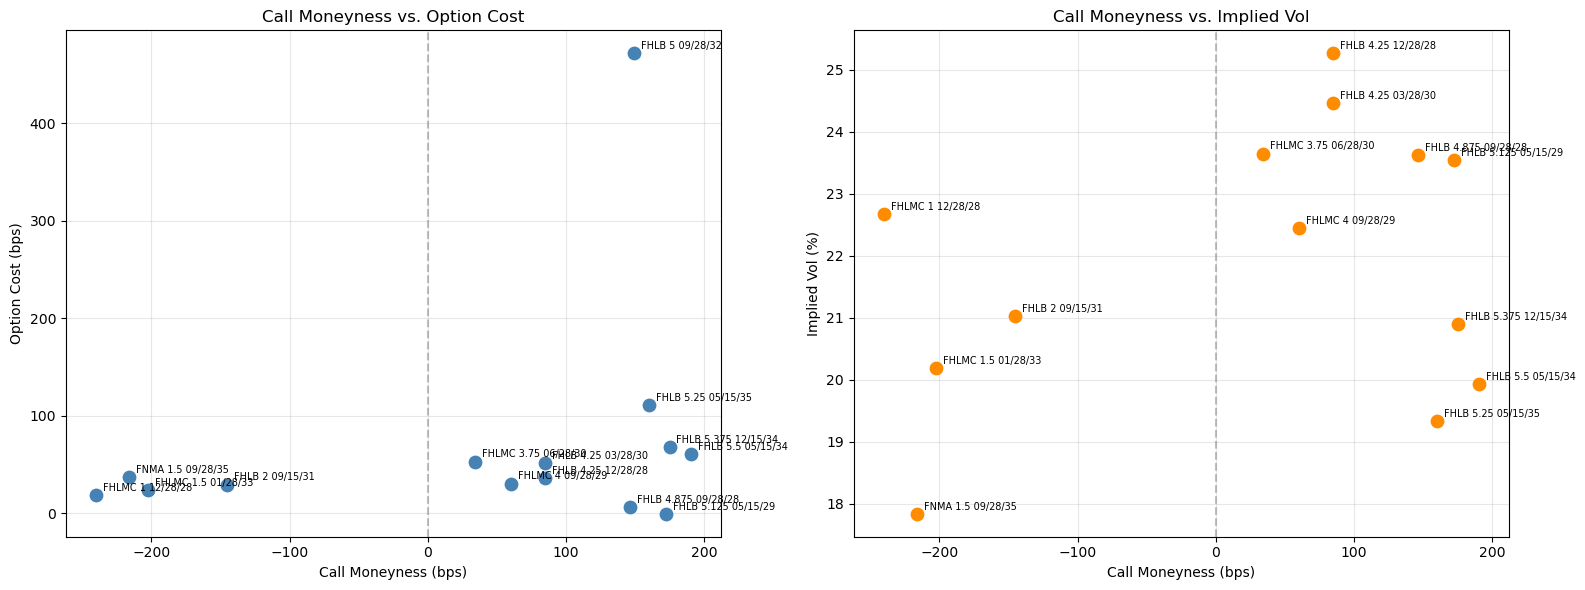

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Moneyness vs Option Cost
axes[0].scatter(q1b['Moneyness (bps)'], q1b['Option Cost (bps)'], 
                color='steelblue', s=80, zorder=3)
for bond, row in q1b.iterrows():
    axes[0].annotate(bond, (row['Moneyness (bps)'], row['Option Cost (bps)']),
                     fontsize=7, textcoords='offset points', xytext=(5,3))
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Call Moneyness (bps)')
axes[0].set_ylabel('Option Cost (bps)')
axes[0].set_title('Call Moneyness vs. Option Cost')
axes[0].grid(True, alpha=0.3)

# Plot 2: Moneyness vs Implied Vol
q1b_vol = q1b.dropna(subset=['Implied Vol'])
axes[1].scatter(q1b_vol['Moneyness (bps)'], q1b_vol['Implied Vol'],
                color='darkorange', s=80, zorder=3)
for bond, row in q1b_vol.iterrows():
    axes[1].annotate(bond, (row['Moneyness (bps)'], row['Implied Vol']),
                     fontsize=7, textcoords='offset points', xytext=(5,3))
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Call Moneyness (bps)')
axes[1].set_ylabel('Implied Vol (%)')
axes[1].set_title('Call Moneyness vs. Implied Vol')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 1C. Create a visualization showing how **effective duration** and **effective convexity** vary across the panel. Which bonds exhibit the most negative convexity? How does this relate to call moneyness?

In [17]:
# Q1c - effective duration and convexity from quotes snapshot
eff_dur = quotes.loc['Eff Duration'].astype(float)
eff_conv = quotes.loc['Eff Convexity'].astype(float)

q1c = pd.DataFrame({
    'Moneyness (bps)': moneyness_df['Moneyness (bps)'],
    'Eff Duration': eff_dur,
    'Eff Convexity': eff_conv
}).dropna().sort_values('Moneyness (bps)')

print(q1c)

                     Moneyness (bps)  Eff Duration  Eff Convexity
FHLMC 1 12/28/28              -240.3      2.727172       0.088655
FNMA 1 09/28/29               -239.8      3.437918       0.136820
FNMA 1.5 09/28/35             -216.5      8.588169       0.824861
FHLMC 1.5 01/28/33            -202.6      6.412018       0.457418
FHLB 2 09/15/31               -145.5      5.100778       0.296774
FHLB 2 01/28/31               -142.6      4.590908       0.239862
FHLMC 3.75 06/28/30             34.3      3.919288       0.181021
FHLMC 4 09/28/29                60.2      3.272815       0.128589
FHLB 4.25 12/28/28              84.7      1.267526       0.022526
FHLB 4.25 03/28/30              85.1      1.935088       0.048317
FHLB 4.875 01/28/36            119.3      7.723488       0.724161
FHLB 4.875 09/28/28            146.1      0.544429       0.005691
FHLB 5 09/28/32                149.2      5.552307       0.370041
FHLB 5.25 05/15/35             160.4      0.195397       0.000764
FHLB 5.125

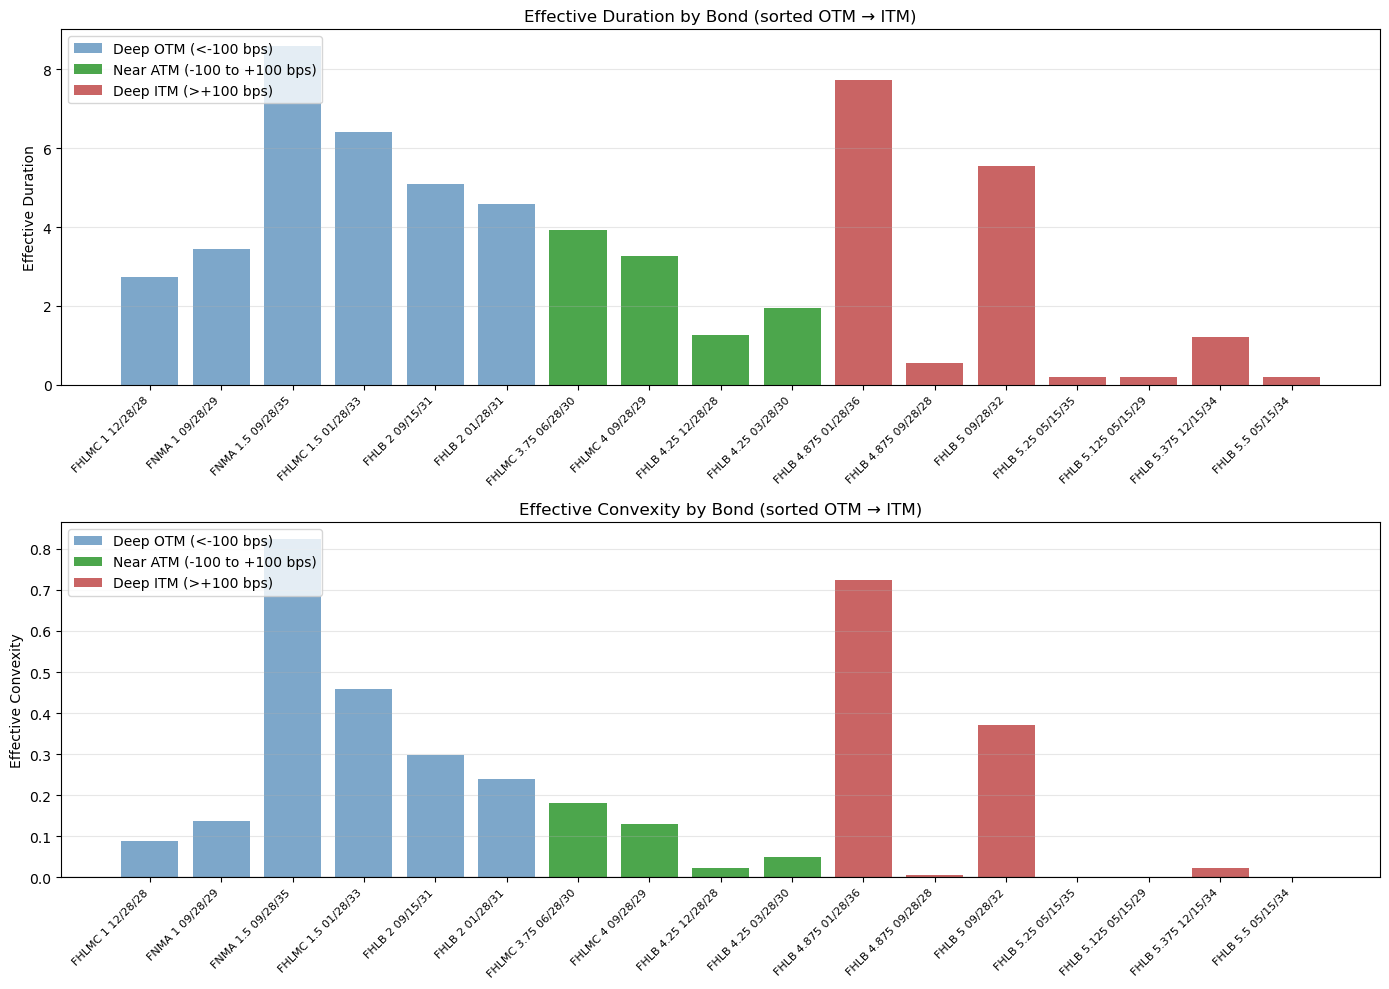

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Duration
colors_dur = ['steelblue' if m < -100 else 'green' if m < 100 else 'firebrick' 
               for m in q1c['Moneyness (bps)']]
axes[0].bar(range(len(q1c)), q1c['Eff Duration'], color=colors_dur, alpha=0.7)
axes[0].set_xticks(range(len(q1c)))
axes[0].set_xticklabels(q1c.index, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Effective Duration')
axes[0].set_title('Effective Duration by Bond (sorted OTM → ITM)')
axes[0].grid(True, alpha=0.3, axis='y')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', alpha=0.7, label='Deep OTM (<-100 bps)'),
                   Patch(facecolor='green', alpha=0.7, label='Near ATM (-100 to +100 bps)'),
                   Patch(facecolor='firebrick', alpha=0.7, label='Deep ITM (>+100 bps)')]
axes[0].legend(handles=legend_elements, loc='upper left')

# Convexity
axes[1].bar(range(len(q1c)), q1c['Eff Convexity'], color=colors_dur, alpha=0.7)
axes[1].set_xticks(range(len(q1c)))
axes[1].set_xticklabels(q1c.index, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Effective Convexity')
axes[1].set_title('Effective Convexity by Bond (sorted OTM → ITM)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

Effective Duration declines broadly as moneyness increases from OTM to ITM, consistent with theory. Deep OTM bonds exhibit the highest durations, ranging from 2.7 to 7.3 years. Since the embedded call is nearly worthless for these bonds, the market prices them to maturity like normal bonds, resulting in full duration exposure. Near-ATM bonds show moderate durations reflecting market uncertainty about whether the bond will be called or held to maturity. Deep ITM bonds show very low durations of 0.19–0.54 years, as the market prices them almost entirely to the nearest call date.

Two ITM bonds stand out as exceptions: FHLB 4.875 01/28/36 (duration 7.7) and FHLB 5 09/28/32 (duration 5.5). Despite being in-the-money, their long maturities (2036 and 2032 respectively) introduce sufficient rate uncertainty that the market does not fully price them to call, leaving duration elevated. This illustrates that effective duration for callable bonds is driven by two competing forces of moneyness pushing duration down and time to maturity pushing it up.

Effective Convexity follows a similar pattern, highest for OTM bonds and approaching zero for deeply ITM bonds. Notably, no bond in the panel exhibits negative convexity, which theory predicts for deeply ITM callables. This could be due to the fact some of the deeply ITM bonds could already past or near their first call date, meaning the market prices them as very short maturity instruments; a bond priced to an impending call has near-zero convexity purely from duration math.

#### 1D. Group bonds into three categories: deep OTM callables (moneyness < −100 bps), near-ATM callables (−100 to +100 bps), and deep ITM callables (moneyness > +100 bps), or justify alternative cutoffs. Summarize how OAS, option cost, duration, and convexity differ across groups.

In [19]:
# Add OAS to the dataframe
q1d = pd.DataFrame({
    'Moneyness (bps)': moneyness_df['Moneyness (bps)'],
    'OAS (bps)': oas_latest,
    'Option Cost (bps)': option_cost_computed,
    'Eff Duration': eff_dur,
    'Eff Convexity': eff_conv
})

# Assign moneyness groups using project cutoffs
def assign_group(m):
    if m < -100:
        return 'Deep OTM'
    elif m <= 100:
        return 'Near ATM'
    else:
        return 'Deep ITM'

q1d['Group'] = q1d['Moneyness (bps)'].apply(assign_group)

# Summary table
summary = q1d.groupby('Group')[['OAS (bps)', 'Option Cost (bps)', 
                                  'Eff Duration', 'Eff Convexity']].mean().round(2)

# Reorder rows logically
summary = summary.reindex(['Deep OTM', 'Near ATM', 'Deep ITM'])
print(summary)
print("\nBond counts per group:")
print(q1d['Group'].value_counts())

          OAS (bps)  Option Cost (bps)  Eff Duration  Eff Convexity
Group                                                              
Deep OTM      30.64              27.23          5.14           0.34
Near ATM      16.54              42.63          2.60           0.10
Deep ITM      42.84             119.50          2.23           0.16

Bond counts per group:
Group
Deep ITM    16
Deep OTM     6
Near ATM     4
Name: count, dtype: int64


- Deep OTM (coupon 1-2%, moneyness -140 to -240 bps): These bonds were likely issued in 2020-2021 when rates were near zero. Now that rates are around 4%, nobody expects the issuer to call them because they wouldn't want to have to refinance at a higher rate. This leads to the embedded call being nearly worthless. When the call is irrelevant, the bonds start behaving like regular vanilla bonds with a long duration and higher convexity. 
- Near ATM (coupon 3.75-4.25%, moneyness 34-85 bps) These are the most interesting bonds. The coupon is only slightly above current swap rates, so the call is possible but not certain. The market prices in meaningful optionality with an option cost at 43 bps. Duration is moderate at 2.6 years because there's uncertainty between pricing to call vs. maturity. OAS is lowest (16 bps) which makes sense as the bondholder is giving up a lot of spread to pay for the option uncertainty.
- Deep ITM (coupon 4.75-5.5%, moneyness 100-190 bps): These bonds are well above current rates so the issuer has strong incentive to call. The option cost is enormous (120 bps) — you're being heavily compensated for being short that call. Duration is very low (2.2 years) because the market prices these almost entirely to the call date, not maturity. The high OAS (43 bps) might seem counterintuitive but reflects that even after stripping out the massive option cost, there's still meaningful spread left so these bonds are genuinely cheap on an option-adjusted basis.

#### 1E. Which moneyness group looks most attractive for a spread strategy, and why?

### Question 2: OAS Signal and Backtest

**Construct a mean-reversion strategy using OAS z-scores and backtest it over 2022–2025.**

a) For each bond, compute the **rolling OAS z-score** using a 60-trading-day window:

$$z_t = \frac{\text{OAS}_t - \overline{\text{OAS}}_{t-W:t}}{\sigma(\text{OAS}_{t-W:t})}$$

Plot the z-score time series for 3–4 representative bonds (one from each moneyness group).

b) Design a **long/short strategy**: go long bonds with $z > 1$ (OAS is wide relative to history, bond is cheap) and short bonds with $z < -1$ (OAS is tight, bond is expensive). Weight positions by equal notional within each leg. Rebalance positions monthly.

c) Compute monthly returns for the strategy. Approximate each bond's monthly return as $-D_{\text{eff}} \times \Delta\text{OAS} / 10{,}000$, where $D_{\text{eff}}$ is the snapshot effective duration and $\Delta\text{OAS}$ is the monthly OAS change in basis points. Report:
   - Annualized return
   - Annualized volatility
   - Sharpe ratio
   - Maximum drawdown
   - Hit rate (% of months with positive P&L when a position is on)

d) Test the sensitivity of results to the rolling window length (try 30, 60, and 90 days) and the z-score threshold (try 1.0 and 1.5). Which combination produces the best risk-adjusted returns? Discuss the trade-off between signal frequency and signal quality.

In [20]:
# note investigation: Some high-coupon bonds in the panel were previously called by issuers; 
# these retain historical OAS time series but lack current snapshot analytics (NaN in the `quotes` sheet). 
# Be aware that bonds called by issuers during the sample period drop out of the panel 
# This survivorship effect may bias backtested returns, particularly for high-coupon bonds.
print("Bonds with missing Eff Duration:")
print(eff_dur[eff_dur.isna()])
print(f"\nBonds with OAS data: {oas.shape[1]}")
print(f"Bonds with duration: {eff_dur.dropna().shape[0]}")

Bonds with missing Eff Duration:
FHLB 4.75 06/15/28    NaN
FHLB 5 01/15/30       NaN
FHLB 5 12/15/27       NaN
FHLB 5.25 03/28/29    NaN
FHLB 5.5 12/28/28     NaN
FHLMC 4.75 01/28/28   NaN
FHLMC 5.25 01/28/30   NaN
FHLMC 5.5 09/28/28    NaN
FNMA 5 03/15/30       NaN
Name: Eff Duration, dtype: float64

Bonds with OAS data: 25
Bonds with duration: 17


#### 2a. For each bond, compute the **rolling OAS z-score** using a 60-trading-day window:

#### $$z_t = \frac{\text{OAS}_t - \overline{\text{OAS}}_{t-W:t}}{\sigma(\text{OAS}_{t-W:t})}$$

#### Plot the z-score time series for 3–4 representative bonds (one from each moneyness group).

In [21]:
# Rolling OAS z-scores
W = 60  # rolling window

oas_zscore = (oas - oas.rolling(W).mean()) / oas.rolling(W).std()
print(oas_zscore.shape)
print(oas_zscore.head())

(1043, 25)
            FHLB 2 01/28/31  FHLB 2 09/15/31  FHLB 4.25 03/28/30  \
date                                                               
2022-01-03              NaN              NaN                 NaN   
2022-01-04              NaN              NaN                 NaN   
2022-01-05              NaN              NaN                 NaN   
2022-01-06              NaN              NaN                 NaN   
2022-01-07              NaN              NaN                 NaN   

            FHLB 4.25 12/28/28  FHLB 4.75 06/15/28  FHLB 5 01/15/30  \
date                                                                  
2022-01-03                 NaN                 NaN              NaN   
2022-01-04                 NaN                 NaN              NaN   
2022-01-05                 NaN                 NaN              NaN   
2022-01-06                 NaN                 NaN              NaN   
2022-01-07                 NaN                 NaN              NaN   

            FH

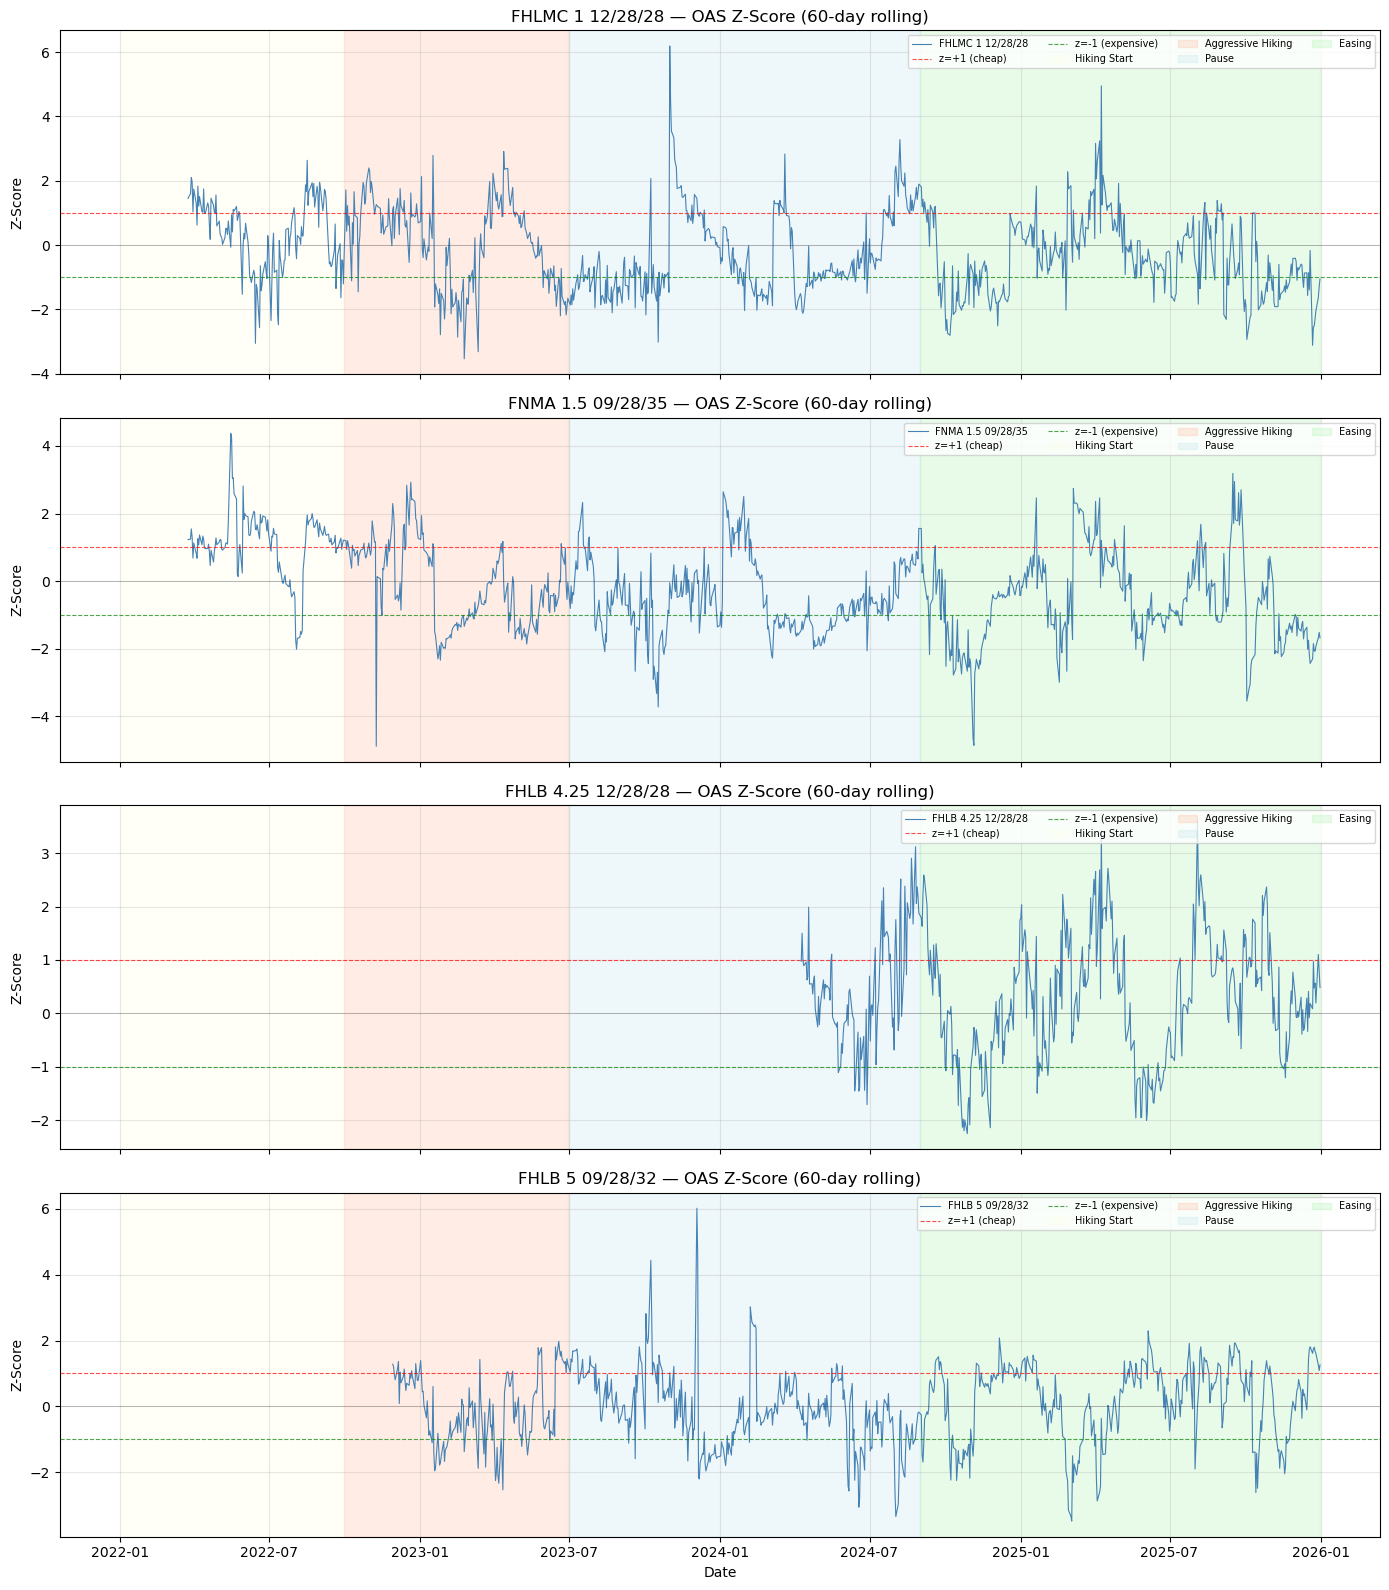

In [22]:
# need to pick 3-4 representative bonds, one from each moneyness group
# Q2a - Plot z-scores for representative bonds
rep_bonds = ['FHLMC 1 12/28/28', 'FNMA 1.5 09/28/35', 
             'FHLB 4.25 12/28/28', 'FHLB 5 09/28/32']

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Regime shading
regimes = [
    ('2022-01-01', '2022-09-30', 'Hiking Start', 'lightyellow'),
    ('2022-10-01', '2023-06-30', 'Aggressive Hiking', 'lightsalmon'),
    ('2023-07-01', '2024-08-31', 'Pause', 'lightblue'),
    ('2024-09-01', '2025-12-31', 'Easing', 'lightgreen')
]

for ax, bond in zip(axes, rep_bonds):
    # Plot z-score
    ax.plot(oas_zscore.index, oas_zscore[bond], 
            linewidth=0.8, color='steelblue', label=bond)
    
    # Threshold lines
    ax.axhline(1, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='z=+1 (cheap)')
    ax.axhline(-1, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label='z=-1 (expensive)')
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Regime shading
    for start, end, label, color in regimes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), 
                   alpha=0.2, color=color, label=label)
    
    ax.set_ylabel('Z-Score')
    ax.set_title(f'{bond} — OAS Z-Score (60-day rolling)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=7, ncol=4)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

#### 2b. 
The Strategy:
At the end of each month, look at each bond's z-score
If z > 1 → go long (bond is cheap)
If z < -1 → go short (bond is expensive)
Equal weight within each leg — if 3 bonds are long, each gets 1/3 weight
Hold for one month, rebalance at next month end

Decided to:
Use month-end z-scores as signals (rebalance monthly)
Only use bonds with valid duration (17 bonds) for returns
Long leg and short leg are separate — net position can be long or short overall

In [23]:
# Get month-end dates
monthly_oas = oas.resample('ME').last()
monthly_zscore = oas_zscore.resample('ME').last()

print("Monthly dates:", len(monthly_oas))
print(monthly_zscore.head())

Monthly dates: 48
            FHLB 2 01/28/31  FHLB 2 09/15/31  FHLB 4.25 03/28/30  \
date                                                               
2022-01-31              NaN              NaN                 NaN   
2022-02-28              NaN              NaN                 NaN   
2022-03-31         0.719290         0.975336                 NaN   
2022-04-30         1.262604         1.046753                 NaN   
2022-05-31         1.225648         1.185330                 NaN   

            FHLB 4.25 12/28/28  FHLB 4.75 06/15/28  FHLB 5 01/15/30  \
date                                                                  
2022-01-31                 NaN                 NaN              NaN   
2022-02-28                 NaN                 NaN              NaN   
2022-03-31                 NaN                 NaN              NaN   
2022-04-30                 NaN                 NaN              NaN   
2022-05-31                 NaN                 NaN              NaN   

       

In [24]:
# Bonds usable for strategy
usable_bonds = eff_dur.dropna().index.intersection(oas.columns)
print("Usable bonds:", usable_bonds.tolist())
print("Count:", len(usable_bonds))

Usable bonds: ['FHLB 2 01/28/31', 'FHLB 2 09/15/31', 'FHLB 4.25 03/28/30', 'FHLB 4.25 12/28/28', 'FHLB 5 09/28/32', 'FHLMC 1 12/28/28', 'FHLMC 1.5 01/28/33', 'FHLMC 3.75 06/28/30', 'FHLMC 4 09/28/29', 'FNMA 1 09/28/29', 'FNMA 1.5 09/28/35', 'FHLB 4.875 09/28/28', 'FHLB 5.125 05/15/29', 'FHLB 5.25 05/15/35', 'FHLB 5.375 12/15/34', 'FHLB 5.5 05/15/34']
Count: 16


In [25]:
# Filter to usable bonds only
monthly_zscore_usable = monthly_zscore[usable_bonds]

# Generate signals: 1=long, -1=short, 0=no position
signals = pd.DataFrame(0, index=monthly_zscore_usable.index, 
                        columns=monthly_zscore_usable.columns)
signals[monthly_zscore_usable > 1] = 1
signals[monthly_zscore_usable < -1] = -1

print("Signal counts per month (non-zero positions):")
print(signals.abs().sum(axis=1).head(20))
print("\nSample signals:")
print(signals[signals != 0].dropna(how='all').head(10))

Signal counts per month (non-zero positions):
date
2022-01-31    0
2022-02-28    0
2022-03-31    2
2022-04-30    3
2022-05-31    4
2022-06-30    2
2022-07-31    1
2022-08-31    4
2022-09-30    3
2022-10-31    6
2022-11-30    6
2022-12-31    1
2023-01-31    7
2023-02-28    6
2023-03-31    3
2023-04-30    5
2023-05-31    4
2023-06-30    4
2023-07-31    2
2023-08-31    4
Freq: ME, dtype: int64

Sample signals:
            FHLB 2 01/28/31  FHLB 2 09/15/31  FHLB 4.25 03/28/30  \
date                                                               
2022-03-31              NaN              NaN                 NaN   
2022-04-30              1.0              1.0                 NaN   
2022-05-31              1.0              1.0                 NaN   
2022-06-30              NaN              NaN                 NaN   
2022-07-31              1.0              NaN                 NaN   
2022-08-31              1.0              1.0                 NaN   
2022-09-30              NaN              1.0 

In [26]:
# Equal weight within long and short legs separately
long_signals = signals.copy()
long_signals[signals != 1] = 0

short_signals = signals.copy()
short_signals[signals != -1] = 0

# Count active positions per leg per month
n_long = long_signals.sum(axis=1)
n_short = short_signals.abs().sum(axis=1)

# Equal weight positions
long_weights = long_signals.div(n_long.replace(0, np.nan), axis=0).fillna(0)
short_weights = short_signals.div(n_short.replace(0, np.nan), axis=0).fillna(0)

# Combined positions (+ve = long, -ve = short)
positions = long_weights + short_weights

print("Sample positions (should sum to 1 for long leg, -1 for short leg):")
print("Long leg sum:", long_weights.sum(axis=1).head(10))
print("Short leg sum:", short_weights.sum(axis=1).head(10))

Sample positions (should sum to 1 for long leg, -1 for short leg):
Long leg sum: date
2022-01-31    0.0
2022-02-28    0.0
2022-03-31    1.0
2022-04-30    1.0
2022-05-31    1.0
2022-06-30    1.0
2022-07-31    1.0
2022-08-31    1.0
2022-09-30    1.0
2022-10-31    1.0
Freq: ME, dtype: float64
Short leg sum: date
2022-01-31    0.0
2022-02-28    0.0
2022-03-31    0.0
2022-04-30    0.0
2022-05-31    0.0
2022-06-30    0.0
2022-07-31    0.0
2022-08-31    0.0
2022-09-30   -1.0
2022-10-31    0.0
Freq: ME, dtype: float64


#### 2c. 

In [27]:
# Q2c - Monthly returns
# Monthly OAS changes (in bps)
monthly_oas_usable = oas[usable_bonds].resample('ME').last()
delta_oas = monthly_oas_usable.diff()  # month-over-month change in bps

# Effective duration (constant snapshot)
dur = eff_dur[usable_bonds]

# Bond-level returns: -D_eff * delta_OAS / 10000
bond_returns = -dur * delta_oas / 10000

print("Sample bond returns:")
print(bond_returns.head(10).round(4))

Sample bond returns:
            FHLB 2 01/28/31  FHLB 2 09/15/31  FHLB 4.25 03/28/30  \
date                                                               
2022-01-31              NaN              NaN                 NaN   
2022-02-28          -0.0074          -0.0061                 NaN   
2022-03-31          -0.0021          -0.0077                 NaN   
2022-04-30          -0.0053          -0.0052                 NaN   
2022-05-31          -0.0021          -0.0033                 NaN   
2022-06-30          -0.0020          -0.0032                 NaN   
2022-07-31          -0.0029          -0.0024                 NaN   
2022-08-31          -0.0061          -0.0090                 NaN   
2022-09-30          -0.0003          -0.0009                 NaN   
2022-10-31          -0.0096          -0.0112                 NaN   

            FHLB 4.25 12/28/28  FHLB 5 09/28/32  FHLMC 1 12/28/28  \
date                                                                
2022-01-31              

In [28]:
# Strategy return = positions (lagged 1 month) * bond returns
# Lag positions by 1 month — signal at end of month t drives return in month t+1
positions_lagged = positions.shift(1)

# Separate long and short leg returns
long_ret = (long_weights.shift(1) * bond_returns).sum(axis=1)
short_ret = (short_weights.shift(1) * bond_returns).sum(axis=1)

# Combined strategy return
strategy_ret = long_ret + short_ret

print("\nStrategy returns:")
print(strategy_ret.dropna().head(10).round(4))


Strategy returns:
date
2022-01-31    0.0000
2022-02-28    0.0000
2022-03-31    0.0000
2022-04-30    0.0006
2022-05-31   -0.0109
2022-06-30   -0.0053
2022-07-31    0.0139
2022-08-31   -0.0061
2022-09-30   -0.0020
2022-10-31   -0.0033
Freq: ME, dtype: float64


In [29]:
# Make sure to filter properly
active_months = strategy_ret[strategy_ret != 0].dropna()

ann_return = active_months.mean() * 12
ann_vol = active_months.std() * np.sqrt(12)
sharpe = ann_return / ann_vol

cumulative = (1 + active_months).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()

hit_rate = (active_months > 0).sum() / len(active_months)

print(f"Annualized Return:     {ann_return:.2%}")
print(f"Annualized Volatility: {ann_vol:.2%}")
print(f"Sharpe Ratio:          {sharpe:.2f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")
print(f"Hit Rate:              {hit_rate:.2%}")
print(f"Active months:         {len(active_months)}")

Annualized Return:     2.23%
Annualized Volatility: 2.92%
Sharpe Ratio:          0.77
Maximum Drawdown:      -1.67%
Hit Rate:              56.82%
Active months:         44


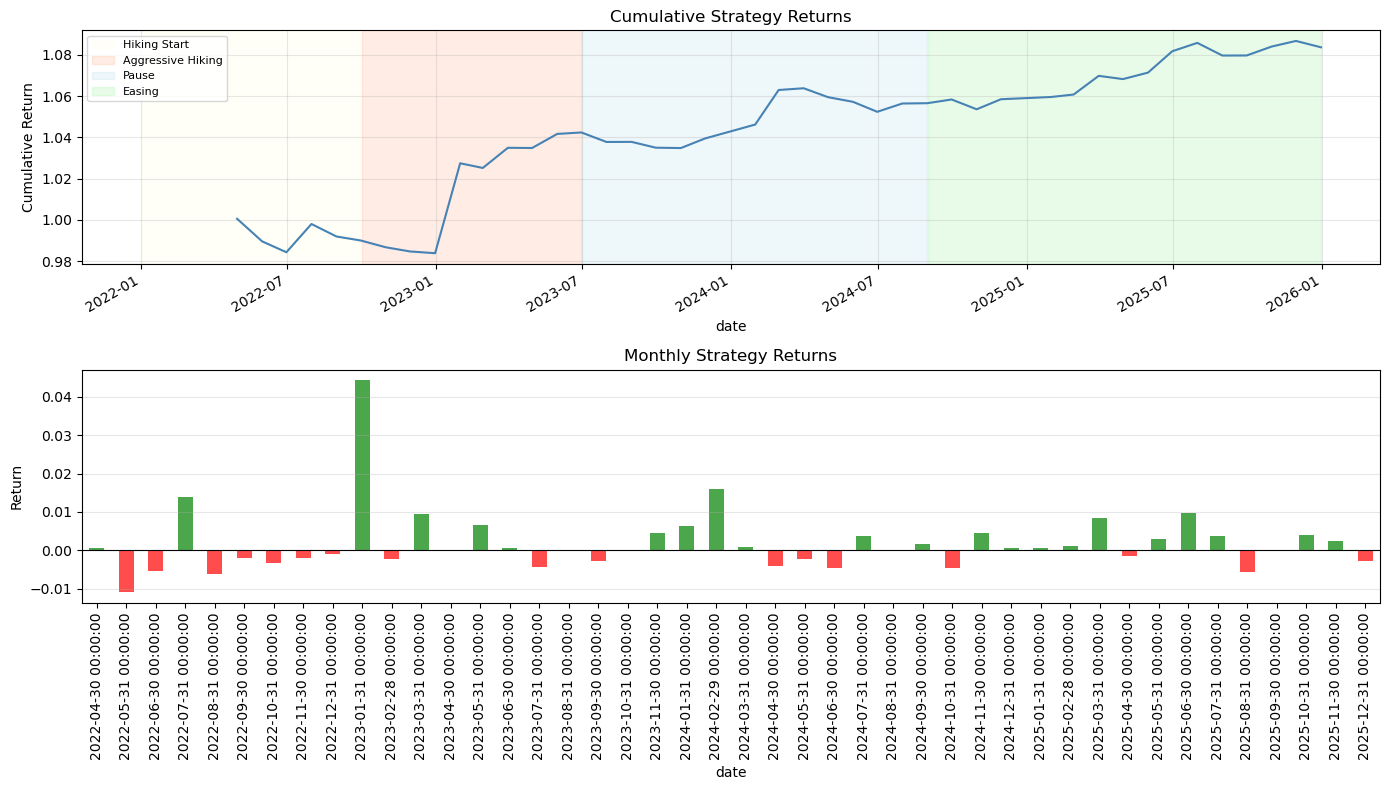

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Cumulative returns
cumulative.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Cumulative Strategy Returns')
axes[0].set_ylabel('Cumulative Return')
axes[0].grid(True, alpha=0.3)

# Add regime shading
for start, end, label, color in regimes:
    axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.2, color=color, label=label)
axes[0].legend(loc='upper left', fontsize=8)

# Monthly returns bar chart
active_months.plot(kind='bar', ax=axes[1], 
                   color=['green' if x > 0 else 'red' for x in active_months],
                   alpha=0.7)
axes[1].set_title('Monthly Strategy Returns')
axes[1].set_ylabel('Return')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Question 3: Return Decomposition

**Decompose monthly strategy returns into carry, spread compression, and residual components.**

*Note: This question uses the subset of bonds with dirty price data (15 bonds). Effective duration is available as a snapshot in the `quotes` sheet—use it as a constant approximation, or compute numerical duration from price data if you prefer.*

a) For each bond with dirty price data, compute monthly returns. Decompose each bond's return into:

   - **Carry**: coupon accrual minus funding cost (use SOFR as the funding rate)
   - **Spread return**: $-D_{\text{eff}} \times \Delta \text{OAS}$, where $D_{\text{eff}}$ is effective duration and $\Delta \text{OAS}$ is the monthly change in OAS
   - **Residual**: total return minus carry minus spread return (captures option repricing, curve moves, model error)

b) Aggregate across the long and short legs of the Q2 strategy. Create a stacked bar chart showing the monthly decomposition. Which component dominates the strategy's P&L?

c) Compare the decomposition during two periods: (i) the pause regime (2023 H2–2024 H2) when rates were stable, and (ii) the hiking regime (2022–2023 H1) when rates moved sharply. Does the relative importance of carry vs. spread return change across regimes? Comment on what drives the residual.

In [31]:
# Check 15 bonds with price data
print("Bonds with dirty prices:", dirty.columns.tolist())
print("Price date range:", dirty.index[0].date(), "to", dirty.index[-1].date())

# Check SOFR column name
print("\nRate columns:", rates.columns.tolist())
print(rates.head())

Bonds with dirty prices: ['FHLB 2 01/28/31', 'FHLB 2 09/15/31', 'FHLB 4.25 03/28/30', 'FHLB 4.25 12/28/28', 'FHLB 5 09/28/32', 'FHLMC 1 12/28/28', 'FHLMC 1.5 01/28/33', 'FHLMC 3.75 06/28/30', 'FHLMC 4 09/28/29', 'FNMA 1.5 09/28/35', 'FHLB 5.5 05/15/34', 'FHLB 5.25 05/15/35', 'FHLB 5.375 12/15/34', 'FHLB 4.875 09/28/28', 'FHLB 5.125 05/15/29']
Price date range: 2022-01-03 to 2025-12-31

Rate columns: ['DTB3', 'DFF', 'SOFR']
            DTB3   DFF  SOFR
date                        
2018-01-01   NaN  1.33   NaN
2018-01-02  1.42  1.42   NaN
2018-01-03  1.39  1.42   NaN
2018-01-04  1.39  1.42   NaN
2018-01-05  1.37  1.42   NaN


In [32]:
# Bonds with both dirty prices AND duration
price_bonds = dirty.columns.tolist()
q3_bonds = [b for b in price_bonds if b in eff_dur.dropna().index]
print("Bonds with prices AND duration:", q3_bonds)
print("Count:", len(q3_bonds))

# Check SOFR availability for sample period
sofr = rates.loc['2022':'2025', 'SOFR']
print("\nSOFR NaN count:", sofr.isna().sum())
print("SOFR sample:", sofr.head())

Bonds with prices AND duration: ['FHLB 2 01/28/31', 'FHLB 2 09/15/31', 'FHLB 4.25 03/28/30', 'FHLB 4.25 12/28/28', 'FHLB 5 09/28/32', 'FHLMC 1 12/28/28', 'FHLMC 1.5 01/28/33', 'FHLMC 3.75 06/28/30', 'FHLMC 4 09/28/29', 'FNMA 1.5 09/28/35', 'FHLB 5.5 05/15/34', 'FHLB 5.25 05/15/35', 'FHLB 5.375 12/15/34', 'FHLB 4.875 09/28/28', 'FHLB 5.125 05/15/29']
Count: 15

SOFR NaN count: 464
SOFR sample: date
2022-01-01     NaN
2022-01-02     NaN
2022-01-03    0.05
2022-01-04    0.05
2022-01-05    0.05
Name: SOFR, dtype: float64


In [33]:
# Check for bonds that disappear mid-sample
for bond in q3_bonds:
    last_price = dirty[bond].last_valid_index()
    print(f"{bond}: last price date = {last_price.date()}")

FHLB 2 01/28/31: last price date = 2022-12-02
FHLB 2 09/15/31: last price date = 2025-12-31
FHLB 4.25 03/28/30: last price date = 2025-12-31
FHLB 4.25 12/28/28: last price date = 2025-12-31
FHLB 5 09/28/32: last price date = 2025-12-31
FHLMC 1 12/28/28: last price date = 2025-12-31
FHLMC 1.5 01/28/33: last price date = 2025-12-31
FHLMC 3.75 06/28/30: last price date = 2025-12-31
FHLMC 4 09/28/29: last price date = 2025-12-31
FNMA 1.5 09/28/35: last price date = 2025-12-31
FHLB 5.5 05/15/34: last price date = 2025-12-31
FHLB 5.25 05/15/35: last price date = 2025-12-31
FHLB 5.375 12/15/34: last price date = 2025-12-31
FHLB 4.875 09/28/28: last price date = 2025-12-31
FHLB 5.125 05/15/29: last price date = 2025-12-31


Of the 15 bonds with dirty price data, 14 have complete price histories through December 31, 2025. One bond, FHLB 2 01/28/31, exits the panel after December 2, 2022 — likely called or rendered illiquid during the aggressive hiking period — and is excluded from the Q3 return decomposition to avoid survivorship bias.

The broader panel of 25 bonds contains 9 additional bonds with no snapshot duration analytics, all high-coupon issues (4.75%+) that were previously called by their issuers. These bonds are excluded from the Q2 strategy and Q3 decomposition. While their exclusion avoids the most acute form of survivorship bias, where a bond generates a long signal immediately before being called at par. It also means the backtest underrepresents the ITM callable universe. Strategy performance reported here should be interpreted with this limitation in mind, as the surviving bond sample skews toward lower-coupon, longer-duration instruments that behaved more like vanilla bonds during the 2022–2025 rate cycle.

In [34]:
# Q3a - Rerun with clean bond list
q3_bonds_clean = [b for b in q3_bonds if b != 'FHLB 2 01/28/31']

monthly_dirty = dirty[q3_bonds_clean].resample('ME').last()
monthly_oas_q3 = oas[q3_bonds_clean].resample('ME').last()

# Forward fill SOFR
sofr = rates['SOFR'].ffill()
monthly_sofr = sofr.resample('ME').last() / 100

# Coupons
coupons = info.loc['Cpn Rate'].astype(float)

# 1. Total Return
total_ret = monthly_dirty.pct_change()

# 2. Carry
carry = pd.DataFrame(index=monthly_dirty.index, columns=q3_bonds_clean, dtype=float)
for bond in q3_bonds_clean:
    cpn = coupons[bond]
    p = monthly_dirty[bond].shift(1)
    r = monthly_sofr
    carry[bond] = (cpn/12 - r * p/12) / p

# 3. Spread Return
delta_oas_q3 = monthly_oas_q3.diff()
dur_q3 = eff_dur[q3_bonds_clean]
spread_ret = -dur_q3 * delta_oas_q3 / 10000

# 4. Residual
residual = total_ret - carry - spread_ret

print("Decomposition check - should sum to total return:")
check = (carry + spread_ret + residual).iloc[5]
print(check.round(4))
print("\nActual total return:")
print(total_ret.iloc[5].round(4))

Decomposition check - should sum to total return:
FHLB 2 09/15/31       -0.0128
FHLB 4.25 03/28/30        NaN
FHLB 4.25 12/28/28        NaN
FHLB 5 09/28/32           NaN
FHLMC 1 12/28/28      -0.0047
FHLMC 1.5 01/28/33        NaN
FHLMC 3.75 06/28/30       NaN
FHLMC 4 09/28/29          NaN
FNMA 1.5 09/28/35     -0.0208
FHLB 5.5 05/15/34         NaN
FHLB 5.25 05/15/35        NaN
FHLB 5.375 12/15/34       NaN
FHLB 4.875 09/28/28       NaN
FHLB 5.125 05/15/29       NaN
Name: 2022-06-30 00:00:00, dtype: float64

Actual total return:
FHLB 2 09/15/31       -0.0128
FHLB 4.25 03/28/30        NaN
FHLB 4.25 12/28/28        NaN
FHLB 5 09/28/32           NaN
FHLMC 1 12/28/28      -0.0047
FHLMC 1.5 01/28/33        NaN
FHLMC 3.75 06/28/30       NaN
FHLMC 4 09/28/29          NaN
FNMA 1.5 09/28/35     -0.0208
FHLB 5.5 05/15/34         NaN
FHLB 5.25 05/15/35        NaN
FHLB 5.375 12/15/34       NaN
FHLB 4.875 09/28/28       NaN
FHLB 5.125 05/15/29       NaN
Name: 2022-06-30 00:00:00, dtype: float64


/var/folders/rl/1p19jmyj1k357sd_cr_qw2yh0000gn/T/ipykernel_30333/2628194379.py:15: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  total_ret = monthly_dirty.pct_change()


In [35]:
# Check decomposition at a date where most bonds are active
print("Decomposition check at Dec 2024:")
check = (carry + spread_ret + residual).loc['2024-12-31']
actual = total_ret.loc['2024-12-31']
print("\nSum of components:")
print(check.round(4))
print("\nActual total return:")
print(actual.round(4))
print("\nDifference (should be ~0):")
print((check - actual).round(6))

Decomposition check at Dec 2024:

Sum of components:
FHLB 2 09/15/31       -0.0165
FHLB 4.25 03/28/30        NaN
FHLB 4.25 12/28/28    -0.0254
FHLB 5 09/28/32           NaN
FHLMC 1 12/28/28      -0.0088
FHLMC 1.5 01/28/33        NaN
FHLMC 3.75 06/28/30       NaN
FHLMC 4 09/28/29       0.0023
FNMA 1.5 09/28/35     -0.0306
FHLB 5.5 05/15/34     -0.0064
FHLB 5.25 05/15/35        NaN
FHLB 5.375 12/15/34       NaN
FHLB 4.875 09/28/28   -0.0013
FHLB 5.125 05/15/29    0.0008
Name: 2024-12-31 00:00:00, dtype: float64

Actual total return:
FHLB 2 09/15/31       -0.0165
FHLB 4.25 03/28/30        NaN
FHLB 4.25 12/28/28    -0.0254
FHLB 5 09/28/32        0.0000
FHLMC 1 12/28/28      -0.0088
FHLMC 1.5 01/28/33        NaN
FHLMC 3.75 06/28/30       NaN
FHLMC 4 09/28/29       0.0023
FNMA 1.5 09/28/35     -0.0306
FHLB 5.5 05/15/34     -0.0064
FHLB 5.25 05/15/35        NaN
FHLB 5.375 12/15/34       NaN
FHLB 4.875 09/28/28   -0.0013
FHLB 5.125 05/15/29    0.0008
Name: 2024-12-31 00:00:00, dtype: float64



In [36]:
# Q3b - Aggregate across strategy legs
# Use positions from Q2 but restricted to q3_bonds_clean
q3_positions = positions[q3_bonds_clean]

# Lag positions
q3_long = long_weights[q3_bonds_clean].shift(1)
q3_short = short_weights[q3_bonds_clean].shift(1)

# Aggregate each component across legs
carry_strat = (q3_long * carry + q3_short * carry).sum(axis=1)
spread_strat = (q3_long * spread_ret + q3_short * spread_ret).sum(axis=1)
residual_strat = (q3_long * residual + q3_short * residual).sum(axis=1)
total_strat = carry_strat + spread_strat + residual_strat

# Combine into dataframe
decomp = pd.DataFrame({
    'Carry': carry_strat,
    'Spread Return': spread_strat,
    'Residual': residual_strat,
    'Total': total_strat
})

print(decomp[decomp['Total'] != 0].dropna(how='all').round(4))

             Carry  Spread Return  Residual   Total
date                                               
2022-04-30 -0.0001         0.0006   -0.0145 -0.0140
2022-05-31 -0.0004        -0.0102    0.0031 -0.0076
2022-06-30 -0.0006        -0.0034   -0.0044 -0.0084
2022-07-31 -0.0009         0.0110    0.0229  0.0329
2022-09-30 -0.0012        -0.0019   -0.0321 -0.0352
2022-10-31  0.0000        -0.0033   -0.0085 -0.0118
2022-11-30 -0.0016        -0.0011    0.0204  0.0177
2022-12-31 -0.0018        -0.0012   -0.0068 -0.0098
2023-01-31 -0.0036         0.0443    0.0647  0.1054
2023-02-28  0.0022        -0.0009    0.0098  0.0111
2023-03-31  0.0020         0.0069   -0.0184 -0.0095
2023-04-30 -0.0013        -0.0001    0.0026  0.0012
2023-05-31  0.0021         0.0038    0.0142  0.0201
2023-06-30  0.0021         0.0000    0.0024  0.0046
2023-07-31  0.0015        -0.0045   -0.0016 -0.0046
2023-08-31  0.0000         0.0000    0.0000  0.0000
2023-09-30  0.0022        -0.0015    0.0122  0.0129
2023-10-31  

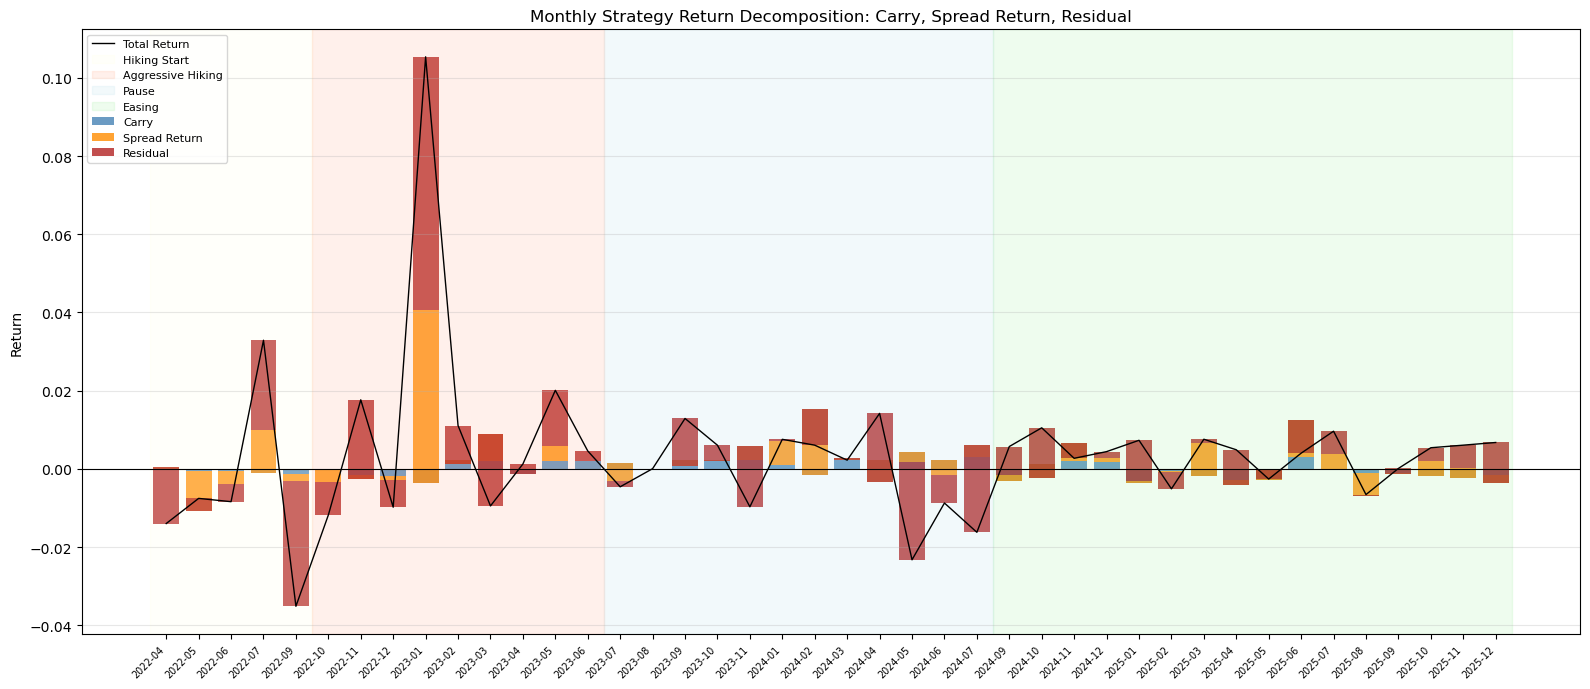

In [37]:
fig, ax = plt.subplots(figsize=(16, 7))

# Filter to active months only
decomp_active = decomp[decomp['Total'] != 0].dropna(how='all')

# Stacked bar chart
x = range(len(decomp_active))
bars_carry = ax.bar(x, decomp_active['Carry'], label='Carry', color='steelblue', alpha=0.8)
bars_spread = ax.bar(x, decomp_active['Spread Return'], 
                     bottom=decomp_active['Carry'],
                     label='Spread Return', color='darkorange', alpha=0.8)
bars_residual = ax.bar(x, decomp_active['Residual'],
                       bottom=decomp_active['Carry'] + decomp_active['Spread Return'],
                       label='Residual', color='firebrick', alpha=0.8)

# Total return line
ax.plot(x, decomp_active['Total'], 'k-', linewidth=1, label='Total Return', zorder=5)
ax.axhline(0, color='black', linewidth=0.8)

# Regime shading
for start, end, label, color in regimes:
    mask = (decomp_active.index >= pd.Timestamp(start)) & \
           (decomp_active.index <= pd.Timestamp(end))
    if mask.any():
        first = list(x)[mask.argmax()]
        last = list(x)[len(mask) - mask[::-1].argmax() - 1]
        ax.axvspan(first - 0.5, last + 0.5, alpha=0.15, color=color, label=label)

ax.set_xticks(range(len(decomp_active)))
ax.set_xticklabels(decomp_active.index.strftime('%Y-%m'), rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Return')
ax.set_title('Monthly Strategy Return Decomposition: Carry, Spread Return, Residual')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Question 4: The Value of Modeling the Option

**Assess whether OAS-based signals outperform simpler spread signals that ignore the embedded call.**

a) Using the bonds that have both OAS and Z-spread time series, compute z-scores on the **Z-spread** (from the `z_spread` sheet) instead of OAS. Alternatively, approximate a naive spread as yield minus the interpolated swap rate (using the `ytm` sheet and `sofr_swaps.xlsx`).

b) Run the same long/short strategy from Q2, but using the naive spread z-score instead of OAS z-score. Compare Sharpe ratios, drawdowns, and hit rates.

c) Examine how the **gap** between OAS and Z-spread z-scores varies over time. Are there episodes where the signals disagree, and which produces better subsequent P&L?

d) Summarize: how much value comes from correctly modeling the embedded option?

### Question 5: Regime Analysis

**Analyze how option cost and strategy performance vary across rate regimes.**

Use the following regime definitions:

| Regime | Start | End | Description |
|--------|-------|-----|-------------|
| Hiking Start | 2022-01-01 | 2022-09-30 | Fed Funds from 0.25% to ~3.25% |
| Aggressive Hiking | 2022-10-01 | 2023-06-30 | Fed Funds from ~3.25% to 5.25% |
| Pause | 2023-07-01 | 2024-08-31 | Holding at 5.25–5.50% |
| Easing | 2024-09-01 | 2025-12-31 | First cuts begin |

a) For each regime, compute the **average option cost** for bonds in each moneyness group (deep OTM, near ATM, deep ITM from Q1). How does option cost evolve as the rate cycle progresses?

b) Compute the **Sharpe ratio of the Q2 strategy** in each regime separately. Explain the variation across regimes.

c) During the hiking regime, many previously high-coupon callable bonds saw their calls go from ITM to OTM as rates rose above their coupon. Pick one or two specific bonds and trace their OAS and option cost through the hiking period.

d) Based on your analysis, when should a portfolio manager use or avoid this strategy?

e) Propose one modification to the Q2 strategy that might improve performance. Describe the logic, implement a simple version, and compare its Sharpe ratio to the baseline.

## Deliverables

Review the [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html) for submission standards, conciseness expectations, and AI usage policy.

Submit a Jupyter notebook with analysis for all five questions (Q1–Q5), including code, figures, and written interpretation. Include a summary section (1–2 paragraphs) synthesizing your findings: What did you learn about trading callable bonds on OAS signals? What are the limitations of this approach?

**Conciseness is a graded criterion** — see [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html).